# Audio Preprocessing for Machine Learning & Deep Learning
## Конспект - краткое рукодвоство


Этот ноутбук служит руководством по предобработке звуковых данных. Он охватывает основные этапы: от загрузки и очистки до извлечения сложных спектральных и кепстральных признаков, а также аугментацию данных.

**Используемые библиотеки:**
*   `librosa`: Основная библиотека для анализа звука.
*   `IPython.display`: Для прослушивания аудио прямо в ноутбуке.



In [90]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import pandas as pd

plt.figure(figsize=(14, 5))


<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

## Раздел 1: Введение и Базовая предобработка

### 1.1 Загрузка аудио и Sample Rate (Частота дискретизации)

Звук в реальном мире — это непрерывная волна (изменение давления воздуха). Чтобы компьютер мог с ним работать, нам нужно превратить этот аналоговый сигнал в цифровую последовательность чисел. Этот процесс называется **дискретизацией** (sampling).



**Sample Rate ($sr$)** — это количество замеров амплитуды сигнала, которое мы делаем за одну секунду. Измеряется в Герцах (Hz).

#### Теорема Котельникова (Найквиста — Шеннона)
Это главное правило цифрового звука. Оно гласит:
> Чтобы корректно восстановить аналоговый сигнал, частота дискретизации ($sr$) должна быть **как минимум в 2 раза выше**, чем самая высокая частота в этом сигнале ($f_{max}$).

$$sr > 2 \cdot f_{max}$$

* **Пример:** Человеческое ухо слышит частоты примерно до **20 000 Гц (20 кГц)**.
* **Следствие:** Чтобы записать звук без потерь для человека, $sr$ должен быть $> 40 000$ Гц. Именно поэтому стандарт Audio CD — **44 100 Гц** (с небольшим запасом).

#### Алиасинг (Aliasing)
Если мы выберем слишком низкий $sr$ (меньше $2 \cdot f_{max}$), высокочастотные сигналы не исчезнут, а **превратятся в низкочастотный шум**. Это называется *Aliasing* (наложение спектров). 
Чтобы избежать этого, перед понижением $sr$ всегда применяется Low-pass фильтр (срезающий высокие частоты). ***librosa.resample*** делает это автоматически.

#### Каналы (Channels)
Звук может быть моно (1 канал) или стерео (2 канала: левый и правый).
* **Для Deep Learning:** В 95% случаев мы конвертируем звук в **MONO**. Это уменьшает размерность входных данных в 2 раза и упрощает архитектуру модели. Стерео нужно только для специфических задач (например, 3D-позиционирование звука).


$$
\begin{aligned}
&\textbf{3D Audio Positioning (Spatial Audio)} \\
&\text{Технология локализации источника звука } S \text{ в точке вектора } \vec{r} \in \mathbb{R}^3. \\
&\text{В отличие от стереопанорамирования (только ось } X \text{), моделируется полное поле:} \\
\\
&\boxed{\text{Stereo (2.0)}} \quad \Rightarrow \quad X: \text{Лево } \leftrightarrow \text{Право} \\
\\
&\boxed{\text{Spatial Audio}} \quad \Rightarrow \quad \begin{cases}
   X \text{ (Azimuth):} & \text{Лево } \leftrightarrow \text{Право} \\
   Y \text{ (Depth):} & \text{Спереди } \leftrightarrow \text{Сзади (Глубина)} \\
   Z \text{ (Elevation):} & \text{Сверху } \leftrightarrow \text{Снизу (Высота)}
\end{cases}
\end{aligned}
$$

#### Выбор sample rate
Чем выше $sr$, тем больше данных (размер входного вектора), что замедляет обучение.

| Sample Rate | Область применения | Почему? |
| :--- | :--- | :--- |
| **44 100 Гц** | Генерация музыки, High-End Audio | Нужно качество полного слышимого диапазона (до 20 кГц). |
| **22 050 Гц** | **Стандарт Librosa**, Классификация музыки | Компромисс. Охватывает частоты до ~11 кГц. Этого достаточно, чтобы различить скрипку и гитару. |
| **16 000 Гц** | **ASR (Распознавание речи)**, NLP | Голос человека редко содержит важную информацию выше 8 кГц. Стандарт для моделей типа Wav2Vec, Whisper (частично). |
| **8 000 Гц** | Телефония | Минимальный стандарт для разборчивости речи. |

Sample Rate: 22050 Hz
Duration: 5.33 seconds
Shape of waveform: (117601,)


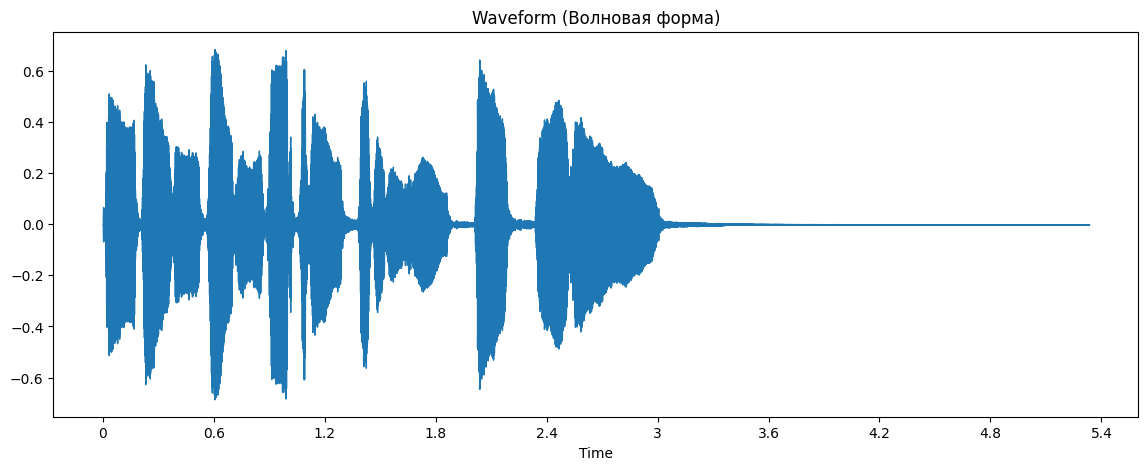

In [91]:
# Загрузка примеров аудио (встроенный трамбон с Librosa)
filename = librosa.ex('trumpet')
y, sr = librosa.load(filename)

print(f"Sample Rate: {sr} Hz")
print(f"Duration: {librosa.get_duration(y=y, sr=sr):.2f} seconds")
print(f"Shape of waveform: {y.shape}")

# Визуализация волновой формы
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform (Волновая форма)")

# Прослушать аудио
ipd.Audio(y, rate=sr)


### 1.2 Resampling (Передискретизация)
Изменение частоты дискретизации необходимо для унификации данных перед подачей в модель.



In [92]:
# Изменение Sample Rate на 16000 Гц
target_sr = 16000
y_resampled = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

print(f"New Sample Rate: {target_sr} Hz")
print(f"New Shape: {y_resampled.shape}")


New Sample Rate: 16000 Hz
New Shape: (85335,)


### 1.3 Удаление тишины (Trimming)
Тишина в начале и конце записи не несет полезной информации, но увеличивает длину входа.



Original Duration: 5.33s
Trimmed Duration: 3.04s


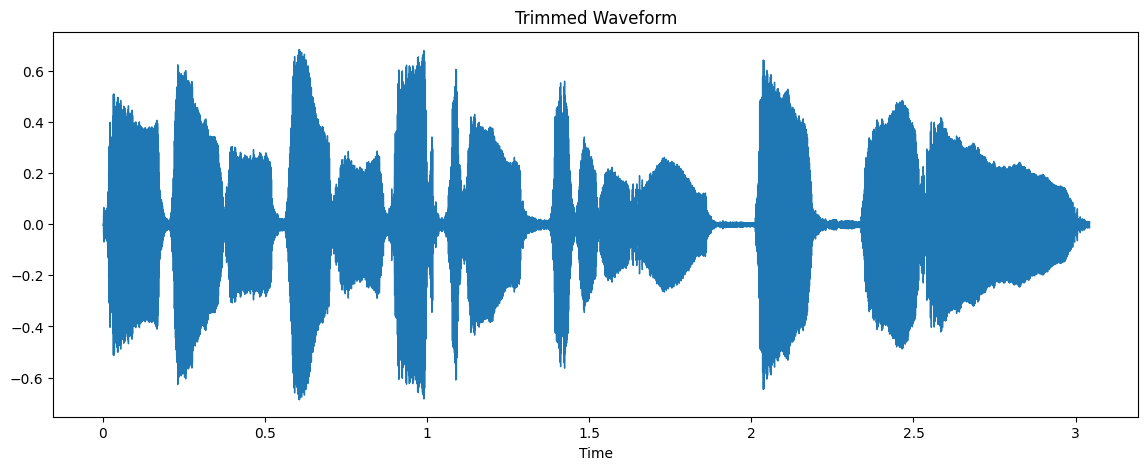

In [93]:
# Удаление тишины (ниже порога 20 дБ)
y_trimmed, index = librosa.effects.trim(y, top_db=20)

print(f"Original Duration: {librosa.get_duration(y=y, sr=sr):.2f}s")
print(f"Trimmed Duration: {librosa.get_duration(y=y_trimmed, sr=sr):.2f}s")

plt.figure(figsize=(14, 5))
librosa.display.waveshow(y_trimmed, sr=sr)
plt.title("Trimmed Waveform")
plt.show()


## Раздел 2: Спектральные представления (Time-Frequency)

Для DL моделей (CNN, RNN, Transformers) сырая волна часто слишком сложна. Мы переходим в частотную область.

### 2.1 Short-Time Fourier Transform (STFT)

Мы разбиваем сигнал на короткие окна и применяем преобразование Фурье к каждому окну. Получаем спектрограмму: зависимость частоты от времени.

**Формула ДПФ (Дискретного Преобразования Фурье):**
$$X_k = \sum_{n=0}^{N-1} x_n e^{-i \frac{2\pi}{N} kn}$$
Где $x_n$ — сигнал, $N$ — размер окна.

### Выбор параметров STFT (Time-Frequency Trade-off)

**1. Принцип неопределенности:**
В обработке сигналов действует правило: нельзя одновременно получить идеальное разрешение и по времени ($\Delta t$), и по частоте ($\Delta f$).
$$ \Delta t \cdot \Delta f \ge \text{const} $$

**2. Почему $n\_fft = 2048$ (при $sr=22050$ Гц)?**
Это золотая середина для музыки.
$$
\begin{aligned}
\text{Разрешение по времени: } & \Delta t = \frac{N}{sr} = \frac{2048}{22050} \approx \mathbf{93 \text{ мс}} \\
\text{Разрешение по частоте: } & \Delta f = \frac{sr}{N} = \frac{22050}{2048} \approx \mathbf{10.7 \text{ Гц}}
\end{aligned}
$$
* $\approx 93$ мс — достаточно длинно, чтобы "услышать" низкие частоты (бас).
* $\approx 10$ Гц — достаточно точно, чтобы различить соседние ноты.
* *Если взять $N=512$, то $\Delta f \approx 43$ Гц $\rightarrow$ низкие ноты сольются в кашу.*

**3. Почему $hop\_length = 512$?**
Стандарт перекрытия окон (Overlap) — $75\%$, чтобы не потерять данные на краях окон (из-за оконной функции Ханна).
$$ hop \approx \frac{n\_fft}{4} = \frac{2048}{4} = 512 $$

**4. Шпаргалка (Cheat Sheet):**
$$
\begin{array}{|l|c|c|l|}
\hline
\textbf{Задача} & \textbf{n\_fft} & \textbf{hop} & \textbf{Логика} \\
\hline
\text{Музыка (General)} & 2048 & 512 & \text{Баланс (ноты + ритм)} \\
\text{Речь (ASR)} & 512 & 160 & \text{Фонемы очень короткие (<50мс)} \\
\text{Ударные (Drums)} & 256 & 64 & \text{Нужна точность момента удара} \\
\hline
\end{array}
$$

Text(0.5, 1.0, 'STFT Spectrogram (Log Frequency)')

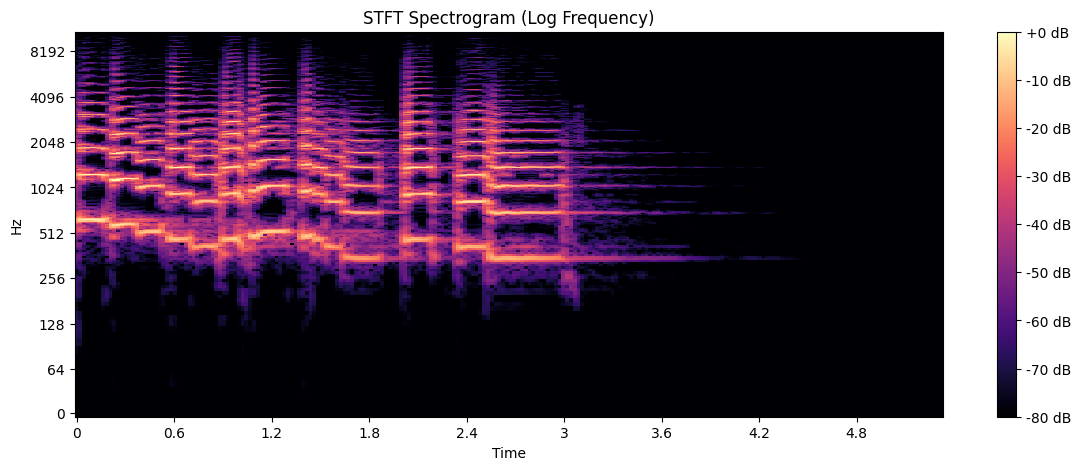

In [94]:
# Вычисление STFT
n_fft = 2048 # Размер окна FFT
hop_length = 512 # Шаг окна

D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("STFT Spectrogram (Log Frequency)")


### 2.2 Mel-Spectrogram (Мел-спектрограмма)

Человеческое ухо воспринимает частоты нелинейно: разница между 100 и 200 Гц нам кажется такой же, как между 1000 и 2000 Гц.
**Мел-шкала (Mel-scale)** моделирует это восприятие.

**Формула перевода Герц в Мелы:**
$$m = 2595 \log_{10}\left(1 + \frac{f}{700}\right)$$




### Почему n_mels = 128?

**1. Спектрограмма как картинка (Image Dimensions)**
В Deep Learning мы подаем спектрограмму в сверточные нейросети (CNN, например, ResNet или EfficientNet), которые изначально создавались для обработки фотографий.
* Параметр `n_mels` становится **высотой** изображения ($Height$).
* Число **128** — это степень двойки ($2^7$).
* GPU обрабатывают данные размером $32, 64, 128, 256$ намного эффективнее, чем, например, $100$ или $150$.
* Размер картинки $128 \times T$ (где $T$ — время) идеально ложится в стандартные архитектуры.

**2. Баланс сжатия и качества**
Обычный STFT (при $n\_fft=2048$) дает нам $1025$ частотных полос. Это слишком много для нейросети (слишком "тяжелый" вход).
Мы сжимаем $1025$ линейных частот в $M$ мел-фильтров.
* **$M = 40$ (MFCC стандарт):** Достаточно, чтобы понять *слова* (речь), но теряется тембр и музыкальные детали.
* **$M = 80$ (Google Tacotron):** Стандарт для синтеза речи (TTS). Хорошо слышен голос, но музыка может звучать "пластмассово".
* **$M = 128$ (Hi-Fi Audio):** "Золотой стандарт" для классификации музыки и генерации качественного звука. Мы сохраняем достаточно деталей, чтобы различить инструменты, но вектор признаков в 8 раз меньше исходного STFT ($1025 \to 128$).

**3. Сравнение стандартов:**
$$
\begin{array}{|l|l|l|}
\hline
\textbf{n\_mels} & \textbf{Область} & \textbf{Комментарий} \\
\hline
32-40 & \text{Распознавание речи (ASR)} & \text{Минимум для понимания слов. Быстрое обучение.} \\
80 & \text{Синтез речи (TTS)} & \text{Стандарт Nvidia/Google (Tacotron, MelGAN).} \\
\mathbf{128} & \textbf{Музыка / DL General} & \textbf{Баланс для CNN. Видны все детали музыки.} \\
256+ & \text{Разделение источников} & \text{Нужно, если разделяем инструменты (Stem Separation).} \\
\hline
\end{array}
$$

Text(0.5, 1.0, 'Log-Mel Spectrogram')

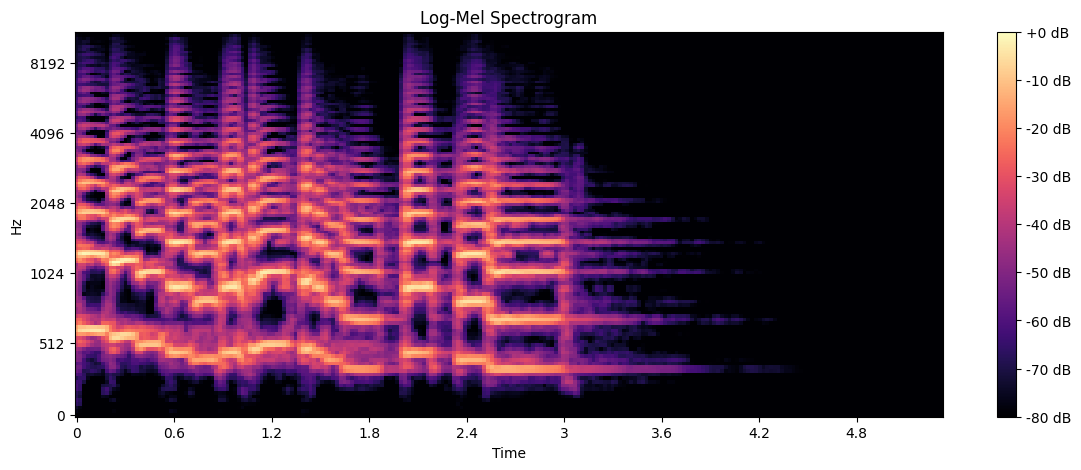

In [95]:
# Генерация Мел-спектрограммы
n_mels = 128 # Количество мел-фильтров

mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)

# Конвертация в децибелы (Log-Mel Spectrogram)
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(mel_spectrogram_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Log-Mel Spectrogram")




### 2.3 Harmonic-Percussive Source Separation (HPSS)

**Суть метода:**
Алгоритм разделяет аудиосигнал $y$ на две составляющие:
1.  **Гармоническая (Harmonic):** Звуки с горизонтальной структурой на спектрограмме (мелодия, голос, музыкальные инструменты).
2.  **Перкуссионная (Percussive):** Звуки с вертикальной структурой (удары барабанов, шум, транзиенты).

$$y(t) = y_{harmonic}(t) + y_{percussive}(t)$$

**Зачем это нужно?**
* **Для анализа ритма:** Проще найти темп (BPM) по $y_{percussive}$, убрав мелодию.
* **Для анализа тональности:** Проще определить ноты/аккорды по $y_{harmonic}$, убрав шум ударных.




Harmonic (Melody):


Percussive (Drums):


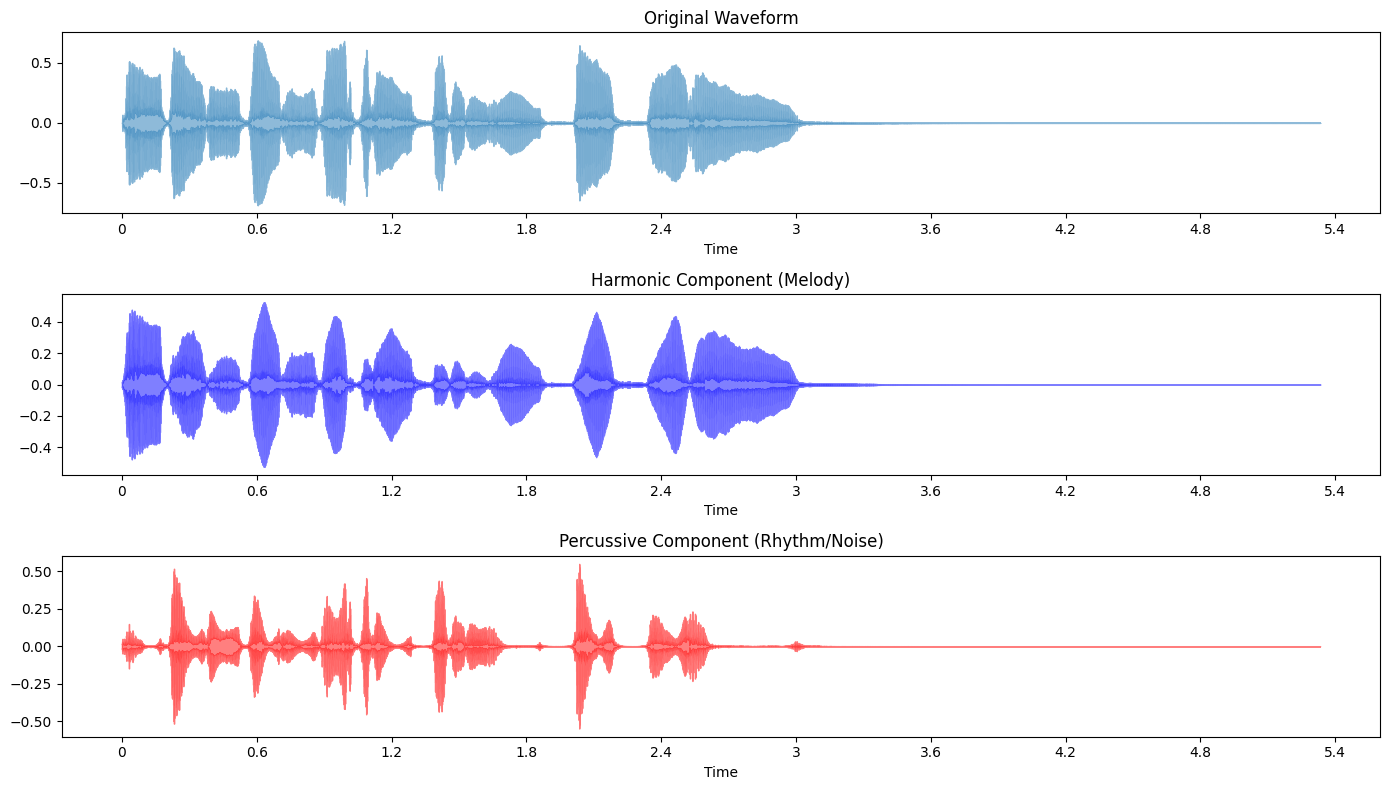

In [96]:
# Разделяем сигнал на гармоническую и перкуссионную части
y_harmonic, y_percussive = librosa.effects.hpss(y)

# Визуализация
plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
librosa.display.waveshow(y, sr=sr, alpha=0.5)
plt.title('Original Waveform')

plt.subplot(3, 1, 2)
librosa.display.waveshow(y_harmonic, sr=sr, alpha=0.5, color='b')
plt.title('Harmonic Component (Melody)')

plt.subplot(3, 1, 3)
librosa.display.waveshow(y_percussive, sr=sr, alpha=0.5, color='r')
plt.title('Percussive Component (Rhythm/Noise)')

plt.tight_layout()

# Слушаем результат 
print("Harmonic (Melody):")
ipd.display(ipd.Audio(y_harmonic, rate=sr))
print("Percussive (Drums):")
ipd.display(ipd.Audio(y_percussive, rate=sr))

## Раздел 3: Кепстральные признаки (Cepstral)

### 3.1 MFCC (Mel-Frequency Cepstral Coefficients)

MFCC — это "спектр спектра". Они компактно описывают форму спектральной огибающей (тембр).
Это стандарт де-факто для распознавания речи (до эры Deep Learning, но всё ещё актуален).

**Процесс:**: STFT -> Power Spectrum -> Mel Filterbank -> Log -> DCT (Discrete Cosine Transform).



Text(0.5, 1.0, 'MFCC')

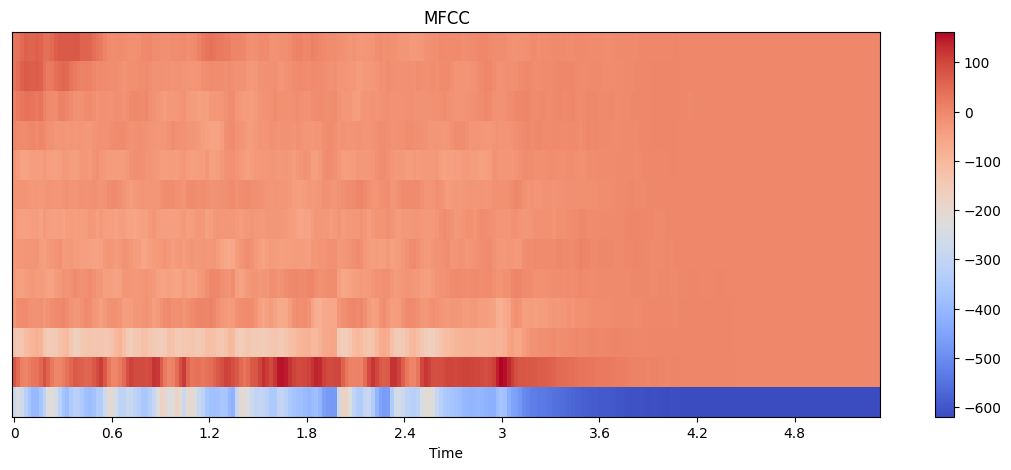

In [97]:
# Извлечение MFCC
n_mfcc = 13 # Обычно используют от 13 до 40 коэффициентов
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

plt.figure(figsize=(14, 5))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title("MFCC")


### 3.2 Delta и Delta-Delta

MFCC описывают статику. Чтобы уловить динамику (как меняется звук), мы берем производные по времени.
*   **Delta**: Первая производная (скорость изменения).
*   **Delta-Delta**: Вторая производная (ускорение).



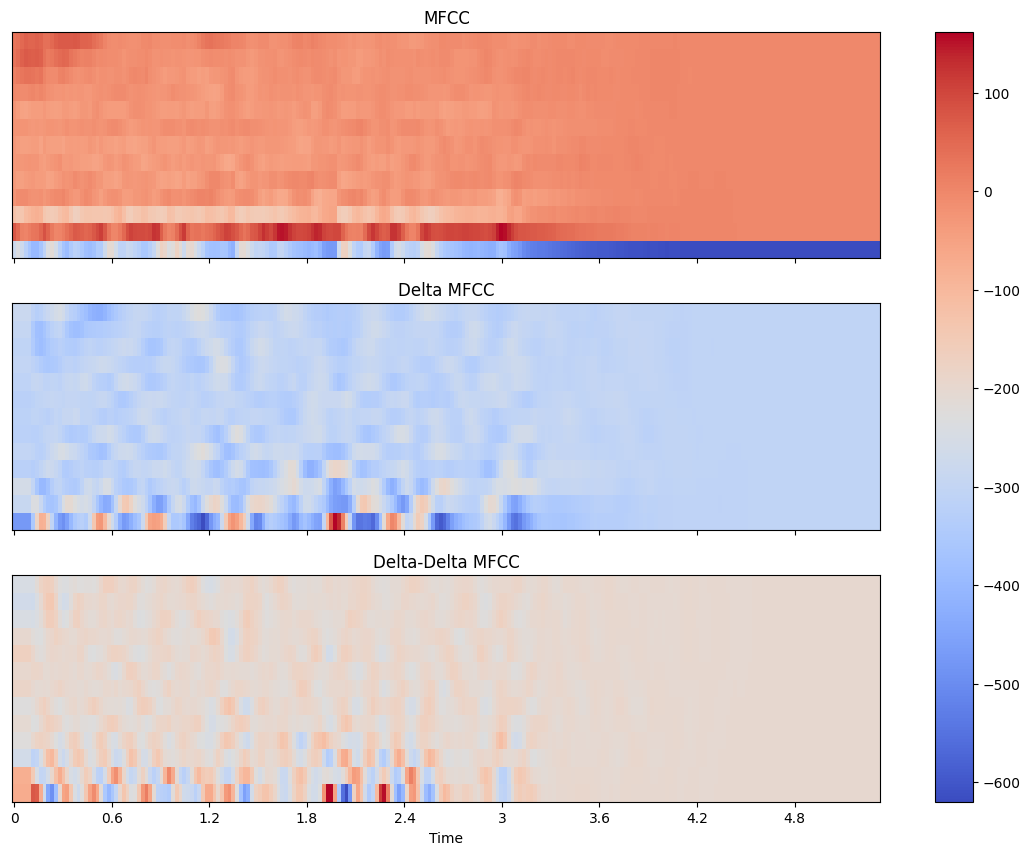

In [98]:
# Вычисление дельт
delta_mfcc = librosa.feature.delta(mfccs)
delta2_mfcc = librosa.feature.delta(mfccs, order=2)

fig, ax = plt.subplots(nrows=3, sharex=True, sharey=True, figsize=(14, 10))
img1 = librosa.display.specshow(mfccs, ax=ax[0], x_axis='time')
ax[0].set(title='MFCC')
ax[0].label_outer()

img2 = librosa.display.specshow(delta_mfcc, ax=ax[1], x_axis='time')
ax[1].set(title='Delta MFCC')
ax[1].label_outer()

img3 = librosa.display.specshow(delta2_mfcc, ax=ax[2], x_axis='time')
ax[2].set(title='Delta-Delta MFCC')
fig.colorbar(img1, ax=ax)



**Интерпретация коэффициентов:**
Обычно берут первые **13-20 коэффициентов**.

* $C_0$: **Энергия сигнала** (Громкость).
* $C_1$: **Спектральный наклон (Spectral Tilt)**. Баланс между низкими и высокими частотами. (Много баса vs Много верха).
* $C_2, C_3 \dots$: Более тонкие детали формы спектра.
* *Высшие коэффициенты:* Быстрые изменения в спектре (шум, "песок"). Их часто отбрасывают, так как они не несут полезной информации о тембре.

$$
\begin{array}{|l|l|}
\hline
\textbf{Плюс} & \textbf{Минус} \\
\hline
\text{Очень компактные (20 чисел вместо 1025)} & \text{Теряется высота тона (не подходит для мелодий)} \\
\text{Отлично разделяет фонемы (слова)} & \text{Не работает на зашумленных данных (шум портит всё)} \\
\text{Декоррелированы (идеально для GMM/HMM)} & \text{В Deep Learning (CNN) чаще берут просто Mel-Spec} \\
\hline
\end{array}
$$

## Раздел 4: Хроматические и Тональные признаки

Эти признаки важны для анализа **музыки** (определение аккордов, тональности, жанра).

### 4.1 Chroma Features (Хромаграмма)
Отображает энергию 12 полутонов октавы (C, C#, D, ...), игнорируя октаву. Показывает гармонический состав.



Text(0.5, 1.0, 'Chroma Features')

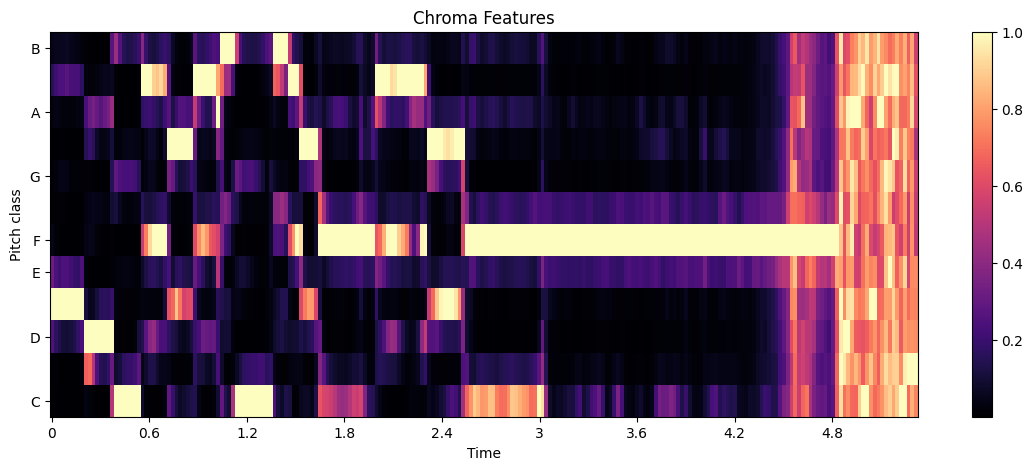

In [99]:
# Chroma STFT
chroma = librosa.feature.chroma_stft(y=y, sr=sr)

plt.figure(figsize=(14, 5))
librosa.display.specshow(chroma, y_axis='chroma', x_axis='time')
plt.colorbar()
plt.title("Chroma Features")


### 4.2 Tonnetz (Tonal Centroids)

**Концепция:**
Tonnetz (нем. *Tone Network*) — это геометрическое представление пространства нот.
Обычная хромаграмма ($12$ измерений) показывает абсолютные ноты ($C, D, E \dots$).
Tonnetz ($6$ измерений) проецирует эти ноты в пространство, где близко находятся не соседние частоты, а **гармонически близкие** звуки (квинтвый круг, терции).



**Математика преобразования:**
Мы преобразуем $12$-мерный вектор Хромы $c$ в $6$-мерный вектор $T$ с помощью проекции на гармонические окружности.

$$ T_d = \frac{1}{\sum c_i} \sum_{i=0}^{11} c_i \cdot \phi_d(i), \quad d \in \{0 \dots 5\} $$

Где $c_i$ — энергия $i$-й ноты хромаграммы, а $\phi_d$ — базисные функции интервалов.

**Что значат эти 6 измерений?**
Пространство разбито на 3 пары координат ($x, y$), каждая отвечает за свой музыкальный интервал:

1.  **5-ths (Квинты):** Измерения $0$ и $1$.
    $$ \phi_{0,1}(i) = \sin / \cos \left( i \cdot \frac{7\pi}{6} \right) $$
    * Описывает положение на **Квинтовом круге** ($C \to G \to D \dots$).
    * Близкие значения $\to$ Тональности близки (например, $C$ maj и $G$ maj).

2.  **Minor 3-rds (Малые терции):** Измерения $2$ и $3$.
    $$ \phi_{2,3}(i) = \sin / \cos \left( i \cdot \frac{3\pi}{6} \right) $$
    * Улавливает связь нот через 3 полутона (как в уменьшенных аккордах).

3.  **Major 3-rds (Большие терции):** Измерения $4$ и $5$.
    $$ \phi_{4,5}(i) = \sin / \cos \left( i \cdot \frac{4\pi}{6} \right) $$
    * Улавливает связь нот через 4 полутона (как в увеличенных аккордах).

$$
\begin{array}{|l|l|}
\hline
\textbf{Применение} & \textbf{Почему Tonnetz лучше Chroma?} \\
\hline
\text{Детекция смены аккордов} & \text{Устойчив к шуму и изменению тембра инструментов.} \\
\text{Определение настроения} & \text{Хорошо разделяет мажор/минор (разные паттерны терций).} \\
\text{Cover Song Identification} & \text{Если кавер сыгран в другом стиле, гармонические связи сохраняются.} \\
\hline
\end{array}
$$

Text(0.5, 1.0, 'Tonnetz Features')

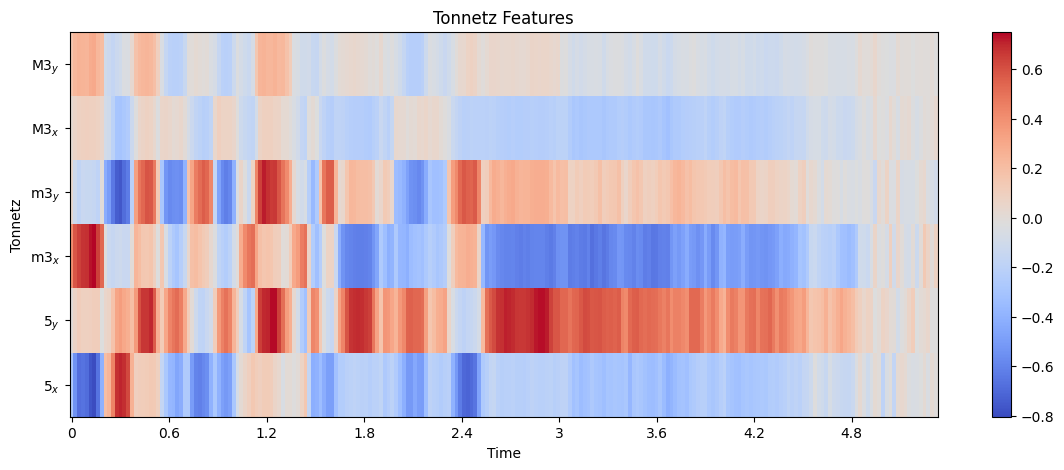

In [100]:
# Tonnetz
# Tonnetz требует гармоническую компоненту
y_harmonic = librosa.effects.harmonic(y)
tonnetz = librosa.feature.tonnetz(y=y_harmonic, sr=sr)

plt.figure(figsize=(14, 5))
librosa.display.specshow(tonnetz, y_axis='tonnetz', x_axis='time')
plt.colorbar()
plt.title("Tonnetz Features")


## Раздел 5: Статистические (Handcrafted) признаки

Простые скалярные значения, описывающие текстуру звука. Часто используются в классическом ML (Random Forest, SVM).

*   **ZCR (Zero Crossing Rate)**: Частота пересечения нуля. Характеризует "шумность" сигнала (высокий ZCR у перкуссии и шума).
*   **RMS (Root Mean Square)**: Энергия (громкость) сигнала.
*   **Spectral Centroid**: "Центр масс" спектра. Ощущается как "яркость" звука.
*   **Spectral Bandwidth**: Ширина полосы частот.
*   **Spectral Contrast**: Разница между пиками и ямами в спектре.



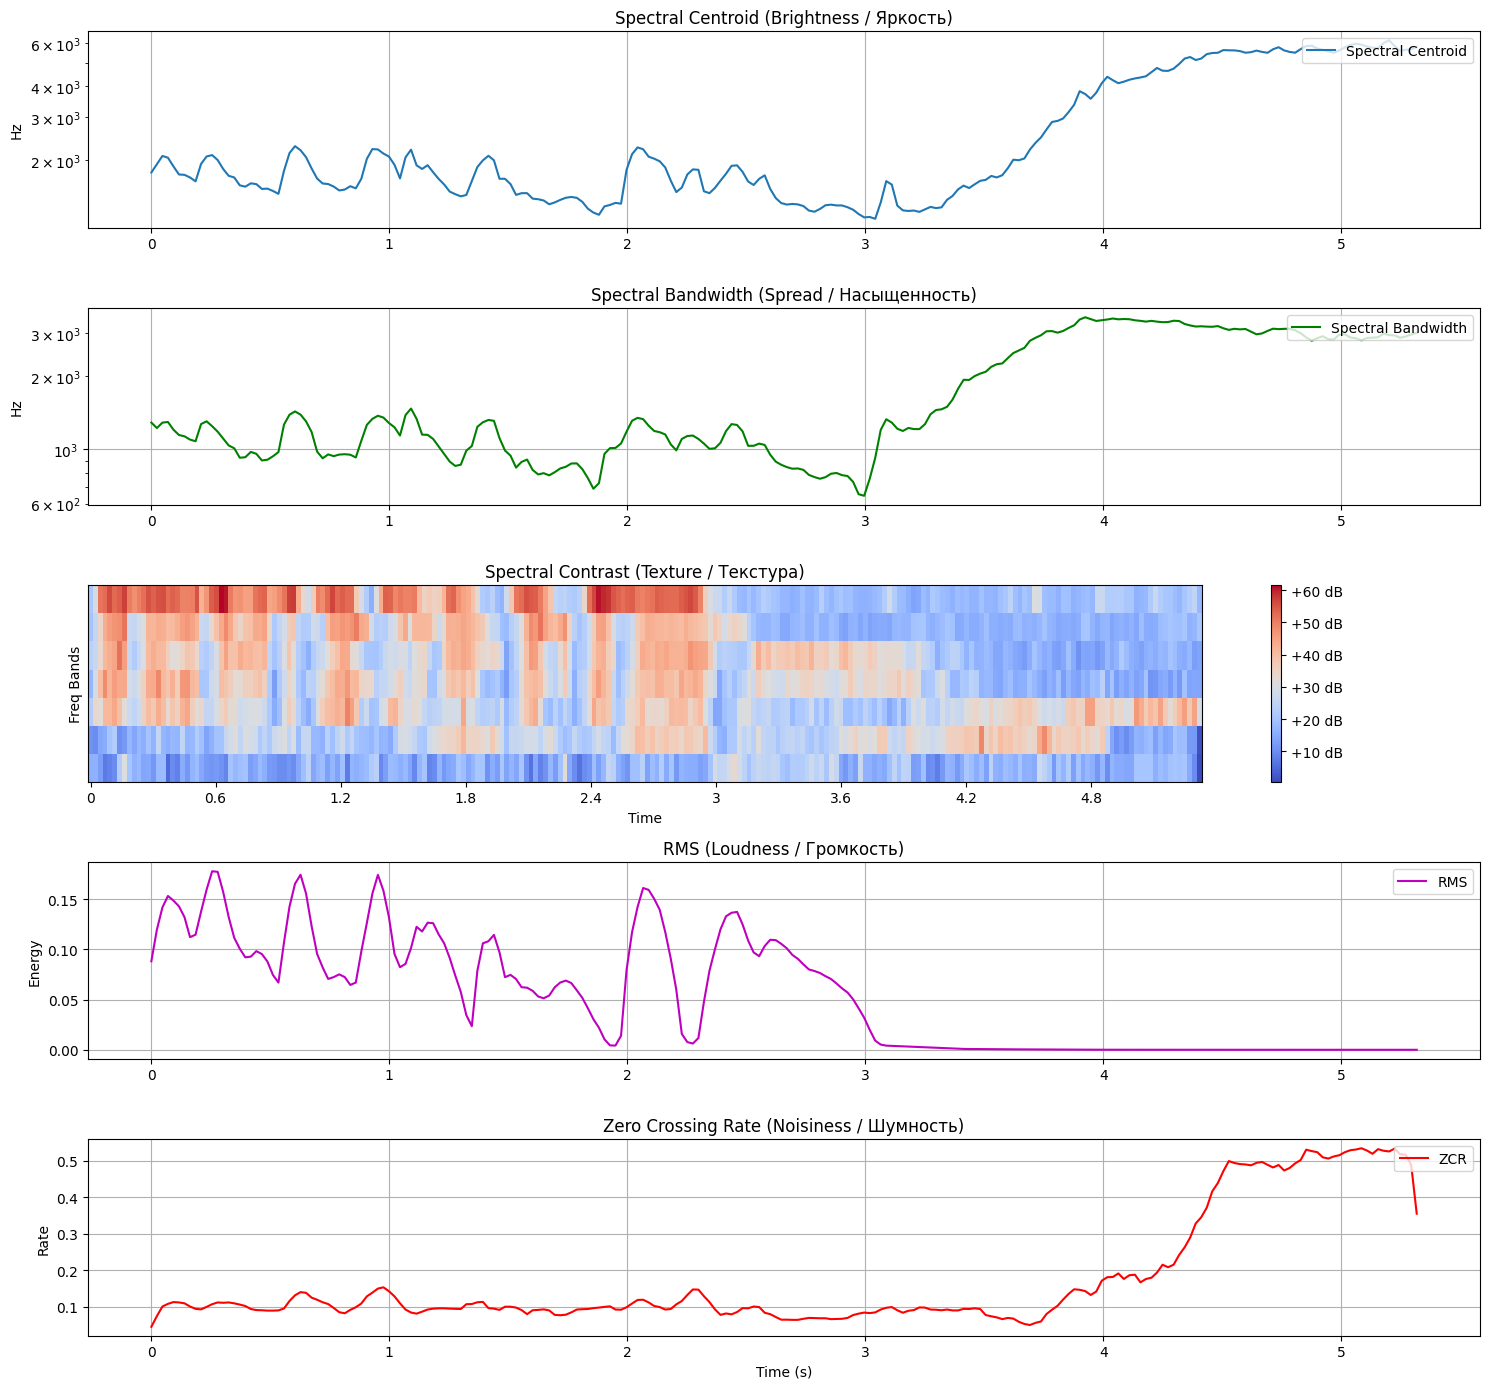

In [ ]:
# ZCR
zcr = librosa.feature.zero_crossing_rate(y)

# RMS
rms = librosa.feature.rms(y=y)

# Spectral Centroid & Bandwidth
cent = librosa.feature.spectral_centroid(y=y, sr=sr)
spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)

# Spectral Contrast
S = np.abs(librosa.stft(y))
contrast = librosa.feature.spectral_contrast(S=S, sr=sr)

# Создаем ось времени для корректного отображения (секунды вместо фреймов)
times = librosa.times_like(zcr)

plt.figure(figsize=(15, 14))

# 1. Spectral Centroid (Яркость)
plt.subplot(5, 1, 1)
plt.semilogy(times, cent.T, label='Spectral Centroid')
plt.ylabel('Hz')
plt.title('Spectral Centroid (Brightness / Яркость)')
plt.legend(loc='upper right')
plt.grid(True)

# 2. Spectral Bandwidth (Ширина полосы)
plt.subplot(5, 1, 2)
plt.semilogy(times, spec_bw.T, label='Spectral Bandwidth', color='g')
plt.ylabel('Hz')
plt.title('Spectral Bandwidth (Spread / Насыщенность)')
plt.legend(loc='upper right')
plt.grid(True)

# 3. Spectral Contrast (Текстура)
plt.subplot(5, 1, 3)
librosa.display.specshow(contrast, x_axis='time', sr=sr, cmap='coolwarm')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectral Contrast (Texture / Текстура)')
plt.ylabel('Freq Bands')

# 4. RMS (Энергия)
plt.subplot(5, 1, 4)
plt.plot(times, rms.T, label='RMS', color='m')
plt.ylabel('Energy')
plt.title('RMS (Loudness / Громкость)')
plt.legend(loc='upper right')
plt.grid(True)

# 5. ZCR (Шумность)
plt.subplot(5, 1, 5)
plt.plot(times, zcr.T, label='ZCR', color='r')
plt.ylabel('Rate')
plt.title('Zero Crossing Rate (Noisiness / Шумность)')
plt.legend(loc='upper right')
plt.xlabel('Time (s)')
plt.grid(True)

plt.tight_layout()


## Раздел 6: Аугментация данных


### Методы:
1.  **Time Stretch**: Изменение скорости без изменения высоты тона.
2.  **Pitch Shift**: Изменение высоты тона без изменения скорости.
3.  **White Noise**: Добавление шума.
4.  **SpecAugment**: Маскирование блоков частот или времени прямо на спектрограмме (очень эффективно для ASR).



Original vs Time Stretch vs Pitch Shift vs Noise


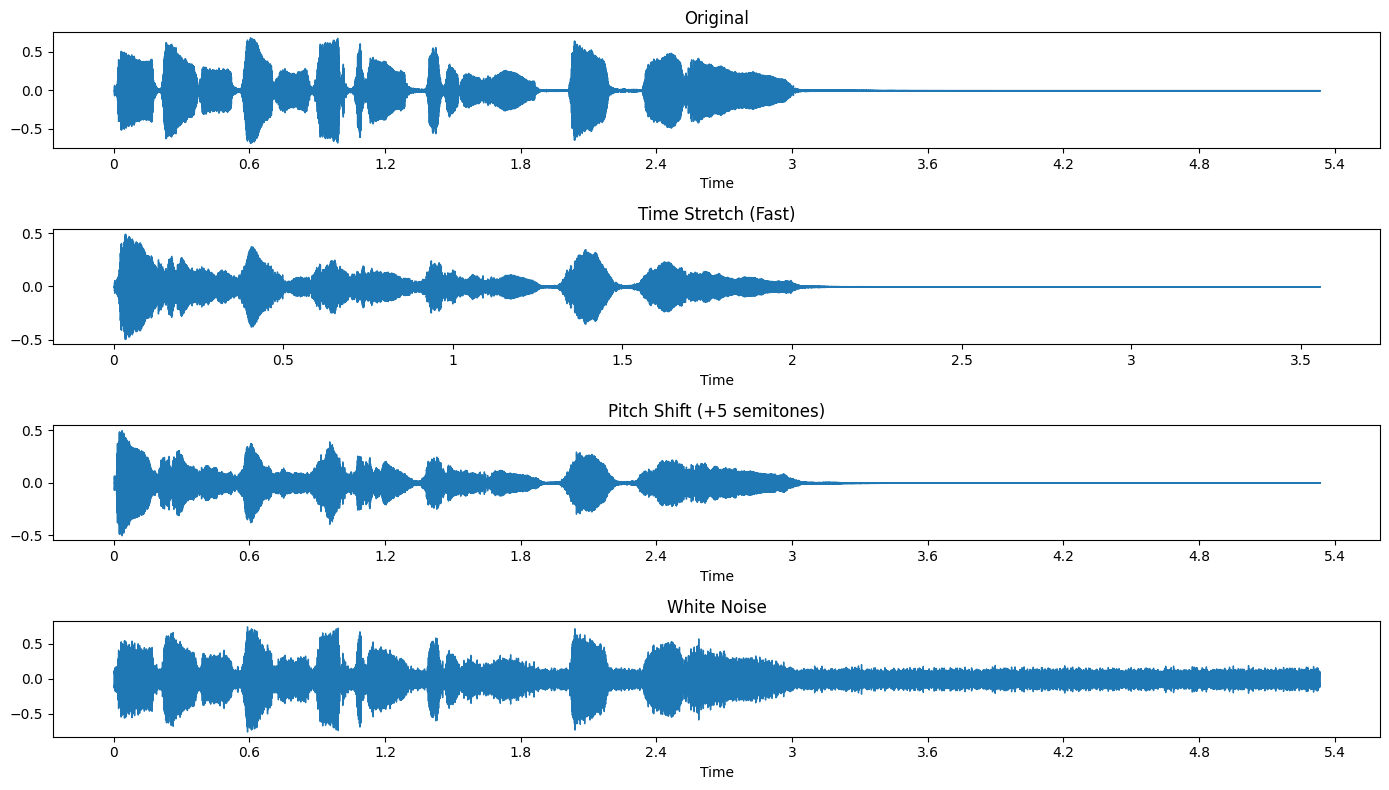

In [102]:
# 1. Time Stretch (Ускорение)
y_fast = librosa.effects.time_stretch(y, rate=1.5)

# 2. Pitch Shift (Повышение тона на 2 полутона)
y_pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=5)

# 3. Добавление Белого Шума
noise = np.random.normal(0, 0.05, len(y))
y_noise = y + noise

# Визуализация и прослушивание
print("Original vs Time Stretch vs Pitch Shift vs Noise")
plt.figure(figsize=(14, 8))
plt.subplot(4, 1, 1); librosa.display.waveshow(y, sr=sr); plt.title("Original")
plt.subplot(4, 1, 2); librosa.display.waveshow(y_fast, sr=sr); plt.title("Time Stretch (Fast)")
plt.subplot(4, 1, 3); librosa.display.waveshow(y_pitch, sr=sr); plt.title("Pitch Shift (+5 semitones)")
plt.subplot(4, 1, 4); librosa.display.waveshow(y_noise, sr=sr); plt.title("White Noise")
plt.tight_layout()


Text(0.5, 1.0, 'SpecAugment (Applied Masking)')

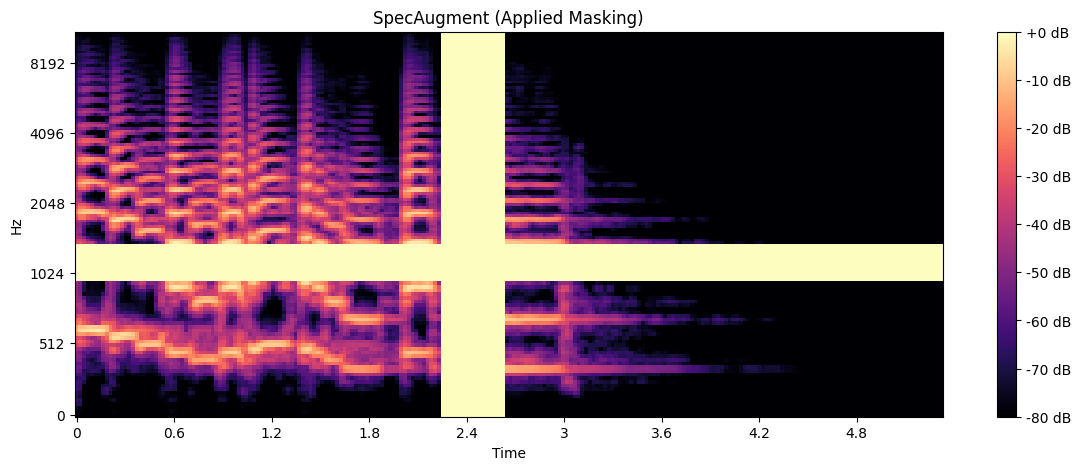

In [103]:
# 4. SpecAugment (Пример маскирования на Log-Mel спектрограмме)
def spec_augment(spec, time_mask_param=10, freq_mask_param=10):
    augmented_spec = spec.copy()
    num_mel_channels, num_time_steps = spec.shape
    
    # Frequency masking
    f = np.random.randint(0, freq_mask_param)
    f0 = np.random.randint(0, num_mel_channels - f)
    augmented_spec[f0:f0+f, :] = 0  # Masking with 0 (silence) or mean
    
    # Time masking
    t = np.random.randint(0, time_mask_param)
    t0 = np.random.randint(0, num_time_steps - t)
    augmented_spec[:, t0:t0+t] = 0
    
    return augmented_spec

augmented_mel = spec_augment(mel_spectrogram_db, time_mask_param=40, freq_mask_param=20)

plt.figure(figsize=(14, 5))
librosa.display.specshow(augmented_mel, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("SpecAugment (Applied Masking)")


## Заключение: Сводная таблица признаков

| Название преобразования | Ключевая область | DL Важность | Classical ML Важность | Краткое описание |
| :--- | :--- | :--- | :--- | :--- |
| **STFT / Spectrogram** | General Audio | **Высокая** | Низкая | Базовое частотно-временное представление. |
| **Mel-Spectrogram** | Речь, Звуки среды | **Высокая** | Средняя | Спектрограмма, адаптированная под слух человека. |
| **MFCC** | Речь | Средняя | **Высокая** | Компактное описание тембра, стандарт для голосовых задач. |
| **Chroma** | Музыка | Средняя | **Высокая** | Описывает гармонический состав и аккорды. |
| **Tonnetz** | Музыка (Гармония) | Средняя | **Высокая** | Проекция нот в пространство интервалов (квинт, терций). |
| **Spectral Contrast** | Жанры, Текстура | Низкая | **Высокая** | Разница между пиками и ямами спектра. |
| **HPSS** | Препроцессинг | Средняя | Средняя | Разделение на Гармоники (мелодия) и Перкуссию (ритм). |
| **ZCR** | Анализ шумов, VAD | Низкая | Средняя | Полезен для разделения речь/шум/тишина. |
| **Spectral Centroid** | Тембральный анализ | Низкая | Средняя | Описывает "яркость" звука (центр масс спектра). |
| **SpecAugment** | DL Training | **Высокая** | - | Аугментация для повышения устойчивости нейросетей. |